In [2]:
eterna_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_outputs/eterna_data"
rnandria_human_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_outputs/rnandria"
rnandria_pri_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_outputs/rnandria_pri"
ribo_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_outputs/ribonanza"

In [3]:
import os

eterna_model_score_map = {}
for f in os.listdir(eterna_path):
    model = f.split(".")[0]
    with open(f"{eterna_path}/{f}") as fh:
        scores = [float(s) for s in fh.read().split(",")]
    eterna_model_score_map[model] = scores

rnandria_model_score_map = {}
for f in os.listdir(rnandria_human_path):
    model = f.split(".")[0]
    with open(f"{rnandria_human_path}/{f}") as fh:
        scores = [float(s) for s in fh.read().split(",")]
    rnandria_model_score_map[model] = scores

rnandria_pri_model_score_map = {}
for f in os.listdir(rnandria_pri_path):
    model = f.split(".")[0]
    with open(f"{rnandria_pri_path}/{f}") as fh:
        scores = [float(s) for s in fh.read().split(",")]
    rnandria_pri_model_score_map[model] = scores

ribo_model_score_map = {}
for f in os.listdir(ribo_path):
    model = f.split(".")[0]
    with open(f"{ribo_path}/{f}") as fh:
        scores = [float(s) for s in fh.read().split(",")]
    ribo_model_score_map[model] = scores

rnandria_pri_model_score_map.keys()

dict_keys(['ContextFold', 'MXFold2', 'IPKnot', 'RNAStructure', 'SPOT-RNA', 'RNAFold', 'NUPACK', 'ContraFold', 'Simfold', 'EternaFold', 'pKnots', 'MXFold', 'NeuralFold'])

In [4]:
import data_utils as du

def detect_dataset(line):
    ds = line[0]
    if ds == "RNAndria":
        if line[2].startswith("hsa"):
            return "RNAndria miRNA"
        else:
            return "RNAndria mRNA"
    else:
        return ds

with open("data/chemical_mapping_master_file.txt") as fh:
    dsci_data = fh.readlines()

dsci_data = [d.split(", ") for d in dsci_data]

dsci_scores = {"EternaData": {}, "RNAndria mRNA": {}, "RNAndria miRNA": {},"Ribonanza": {}}
for ds in du.chemical_mapping_datasets:
    if ds not in ["EternaData", "RNAndria mRNA", "RNAndria miRNA", "Ribonanza"]:
        continue
    for m in du.models:
        dsci_scores[ds][m] = []

for d in dsci_data:
    ds = detect_dataset(d)
    if ds not in ["EternaData", "RNAndria mRNA", "RNAndria miRNA", "Ribonanza"]:
        if ds != "YesselmanLab":
            print(ds)
        continue
    model = d[1]
    acc = float(d[5])
    try:
        dsci_scores[ds][model].append(acc)
    except Exception as e:
        print(ds)
        print(dsci_scores[ds])
        break



ds_model_map = {
    "EternaData (Eterna Scorer)": eterna_model_score_map,
    "EternaData (DSCI Scorer)": dsci_scores["EternaData"],
    "RNAndria mRNA (Eterna Scorer)": rnandria_model_score_map,
    "RNAndria mRNA (DSCI Scorer)": dsci_scores["RNAndria mRNA"],
    "RNAndria miRNA (Eterna Scorer)": rnandria_pri_model_score_map,
    "RNAndria miRNA (DSCI Scorer)": dsci_scores["RNAndria miRNA"],
    "Ribonanza (Eterna Scorer)": ribo_model_score_map,
    "Ribonanza (DSCI Scorer)": dsci_scores["Ribonanza"]
}

In [5]:
ds_model_map["RNAndria miRNA (DSCI Scorer)"].keys()

dict_keys(['ContextFold', 'ContraFold', 'EternaFold', 'IPKnot', 'MXFold', 'MXFold2', 'NeuralFold', 'NUPACK', 'pKnots', 'RNAFold', 'RNAStructure', 'Simfold', 'SPOT-RNA'])

In [6]:
print("Average scores:")
for m in du.models:
    e_scores = ds_model_map["EternaData (Eterna Scorer)"][m]
    d_scores = ds_model_map["EternaData (DSCI Scorer)"][m]
    e_scores2 = ds_model_map["RNAndria mRNA (Eterna Scorer)"][m]
    d_scores2 = ds_model_map["RNAndria mRNA (DSCI Scorer)"][m]
    e_scores3 = ds_model_map["RNAndria miRNA (Eterna Scorer)"][m]
    d_scores3 = ds_model_map["RNAndria miRNA (DSCI Scorer)"][m]
    e_scores4 = ds_model_map["Ribonanza (Eterna Scorer)"][m]
    d_scores4 = ds_model_map["Ribonanza (DSCI Scorer)"][m]
    eavg = round((sum(e_scores) / len(e_scores)), 4)
    davg = round((sum(d_scores) / len(d_scores)), 4)
    eavg2 = round((sum(e_scores2) / len(e_scores2)), 4)
    davg2 = round((sum(d_scores2) / len(d_scores2)), 4)
    eavg3 = round((sum(e_scores3) / len(e_scores3)), 4)
    davg3 = round((sum(d_scores3) / len(d_scores3)), 4)
    eavg4 = round((sum(e_scores4) / len(e_scores4)), 4)
    davg4 = round((sum(d_scores4) / len(d_scores4)), 4)
    winner1 = "DSCI" if davg > eavg else "Eterna"
    winner2 = "DSCI" if davg2 > eavg2 else "Eterna"
    winner3 = "DSCI" if davg3 > eavg3 else "Eterna"
    winner4 = "DSCI" if davg4 > eavg4 else "Eterna"
    print(f"{m}:")
    print(f"Eterna\t\tEterna Scorer: {eavg}\tDSCI Scorer: {davg}\tWinner {winner1}")
    print(f"RNAndria mRNA\tEterna Scorer: {eavg2}\tDSCI Scorer: {davg2}\tWinner {winner2}")
    print(f"RNAndria miRNA\tEterna Scorer: {eavg3}\tDSCI Scorer: {davg3}\tWinner {winner3}")
    print(f"Ribonanza\tEterna Scorer: {eavg4}\tDSCI Scorer: {davg4}\tWinner {winner4}")


Average scores:
ContextFold:
Eterna		Eterna Scorer: 0.7076	DSCI Scorer: 0.747	Winner DSCI
RNAndria mRNA	Eterna Scorer: 0.6751	DSCI Scorer: 0.6823	Winner DSCI
RNAndria miRNA	Eterna Scorer: 0.6654	DSCI Scorer: 0.6801	Winner DSCI
Ribonanza	Eterna Scorer: 0.653	DSCI Scorer: 0.716	Winner DSCI
ContraFold:
Eterna		Eterna Scorer: 0.7353	DSCI Scorer: 0.7576	Winner DSCI
RNAndria mRNA	Eterna Scorer: 0.7124	DSCI Scorer: 0.7078	Winner Eterna
RNAndria miRNA	Eterna Scorer: 0.7145	DSCI Scorer: 0.6915	Winner Eterna
Ribonanza	Eterna Scorer: 0.6971	DSCI Scorer: 0.7231	Winner DSCI
EternaFold:
Eterna		Eterna Scorer: 0.7427	DSCI Scorer: 0.7615	Winner DSCI
RNAndria mRNA	Eterna Scorer: 0.7294	DSCI Scorer: 0.7222	Winner Eterna
RNAndria miRNA	Eterna Scorer: 0.7299	DSCI Scorer: 0.6999	Winner Eterna
Ribonanza	Eterna Scorer: 0.6967	DSCI Scorer: 0.7315	Winner DSCI
IPKnot:
Eterna		Eterna Scorer: 0.6895	DSCI Scorer: 0.7535	Winner DSCI
RNAndria mRNA	Eterna Scorer: 0.5923	DSCI Scorer: 0.6889	Winner DSCI
RNAndria miRNA	

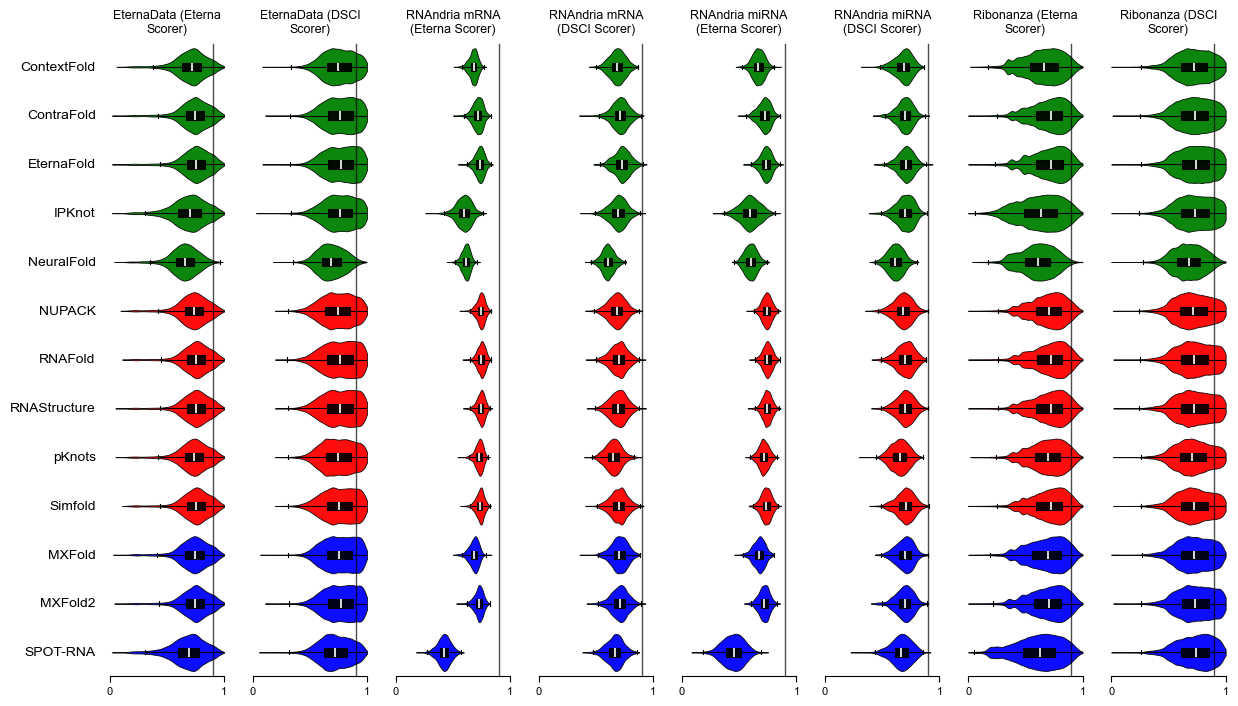

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import textwrap


model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

dataset_order = [
    "EternaData (Eterna Scorer)",
    "EternaData (DSCI Scorer)",
    "RNAndria mRNA (Eterna Scorer)",
    "RNAndria mRNA (DSCI Scorer)",
    "RNAndria miRNA (Eterna Scorer)",
    "RNAndria miRNA (DSCI Scorer)",
    "Ribonanza (Eterna Scorer)",
    "Ribonanza (DSCI Scorer)"
]

n_rows = len(model_order)
n_cols = len(dataset_order)

fig_w = max(1.8 * n_cols, 7)
fig_h = max(0.4 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    for col_idx, dataset in enumerate(dataset_order):
        ax = axes[row_idx, col_idx]

        values = ds_model_map.get(dataset, {}).get(model, [])
        values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            vert=False
        )

        model_color = du.get_model_color(model)

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        # Add inner boxplot inside the violin
        box = ax.boxplot(
            values,
            positions=[0],
            widths=0.18,
            vert=False,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(
                facecolor="black",
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9
            ),
            medianprops=dict(
                color="white",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8
            ),
            capprops=dict(
                color="black",
                linewidth=0.8
            )
        )

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)


        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.5, 0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
            ax.set_xticklabels(["0", "1"])
            ax.tick_params(
                axis="x",
                bottom=True,
                length=4,
                width=0.8,
                labelsize=8
            )
        else:
            ax.set_xticks([])
            ax.tick_params(axis="x", bottom=False)

        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row_idx == n_rows - 1:
            ax.spines["bottom"].set_visible(True)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["bottom"].set_color("black")

        if col_idx == 0:
            ax.set_ylabel(model, rotation=0, ha="right", va="center", labelpad=10)

        if row_idx == 0:
            wrapped_title = "\n".join(textwrap.wrap(dataset, width=18))
            ax.set_title(wrapped_title, fontsize=9, pad=8)

# plt.tight_layout()
# 2d line
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.25,
    top=0.90
)

fig.canvas.draw()

threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

plt.savefig("eterna_vs_dsci.png", dpi=500)
plt.show()

In [19]:
ds_model_map["EternaData (Eterna Scorer)"]["ContextFold"][:10]

[0.5396825396825397,
 0.5303030303030303,
 0.8412698412698413,
 0.8769230769230769,
 0.7627118644067796,
 0.7777777777777778,
 0.8412698412698413,
 0.8636363636363636,
 0.8709677419354839,
 0.9183673469387755]

TypeError: list indices must be integers or slices, not str